# Neural networks for supervised multi-class classification
## Loading libraries
First, load the standard libraries.

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import Neural as Neur

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem setup
We have $n$ input samples in $\mathbb{R}^2$, so $X$ is a $(2,n)$ matrix. The outputs are $n$ vectors of length $3$ equal to $[1,0,0]$, $[0,1,0]$, or $[0,0,1]$; by convention $[1,0,0]$ is the `red` class, $[0,1,0]$ the `green` class, and $[0,0,1]$ the `blue` class. The matrices $X$ of shape $(2,n)$ and $Y$ of shape $(3,n)$ are built by the following code:

In [3]:
n0 = 100 # points per class
n = n0*3 # total number of points
x = np.zeros((2,n))
y = np.zeros((3,n))
for j in np.arange(0,3):
    I = np.arange(n0*(j-1),n0*j) # indices for this class
    r = np.linspace(0.0,1,n0) # radius
    t = np.linspace(j*4,(j+1)*4,n0) + np.random.randn(1,n0)*0.2 # angle
    x[0,I] = r*np.sin(t)
    x[1,I] = r*np.cos(t)
    y[j,I] = 1.
print(x[:,0],y[:,0]) # print first input/output pair

[-0. -0.] [0. 1. 0.]


The code below plots the data; note how `color` is used to color each point with an RGB triple.

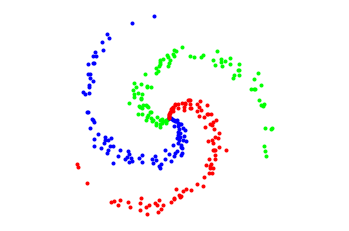

In [4]:
for i in np.arange(n):
    plt.plot(x[0,i], x[1,i], '.', color=y[:,i])
plt.axis('equal')
plt.axis('off');
Z = np.random.randn(3,2)

# Multinomial logistic regression
The network outputs vectors $z\in\mathbb{R}^3$, which are not directly interpretable as class probabilities. We prefer vectors $\tilde y$ with nonnegative entries summing to $1$, interpreted as class probabilities. For example, if $\tilde y=[0.5,0.3,0.2]$, we read probabilities $0.5$ for `red`, $0.3$ for `green`, and $0.2$ for `blue`. For visualization, $\tilde y$ is shown as the RGB color $[0.5,0.3,0.2]$.

The standard map is the `ilogit` transform (inverse logit), defined by
$$ z=\begin{pmatrix} z_1 \\ z_2 \\ z_3 \end{pmatrix} \Rightarrow \tilde y =\frac{1}{\sum_{i=1}^3 e^{z_i}}\begin{pmatrix}e^{z_1}\\ e^{z_2} \\ e^{z_3}\end{pmatrix}$$
The network processes all $n$ samples at once, so $z$ is a $(3,n)$ matrix. Apply the formula column-wise. Call this map `ilogit`. Hint: `a.sum(axis=0)` sums along the first axis (over rows for a matrix), giving one value per column.

In [5]:
def ilogit(z) :
    return 1/(np.sum(np.exp(z), axis=0)) * np.exp(z)

np.random.seed(42)
z=np.random.randn(3,2)  # 2 samples
print('#### : z')
print(z)
ytilde=ilogit(z)
print('#### : y')
print(ytilde)
# You should get
##### : z
#[[ 0.49671415 -0.1382643 ]
# [ 0.64768854  1.52302986]
# [-0.23415337 -0.23413696]]
##### : y
#[[ 0.37814933  0.13937862]
# [ 0.43977514  0.73398479]
# [ 0.18207554  0.12663659]]

#### : z
[[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]
 [-0.23415337 -0.23413696]]
#### : y
[[0.37814933 0.13937862]
 [0.43977514 0.73398479]
 [0.18207554 0.12663659]]


# Loss function
We now implement the cost (loss). With `ilogit`, the usual loss is the logistic loss (Kullback–Leibler divergence). If $\tilde y\in\mathbb{R}^3$ has nonnegative entries summing to $1$, and $y$ is one of $[1,0,0]$, $[0,1,0]$, $[0,0,1]$, measure the mismatch between $\tilde y$ and the true $y$ by
$$d_{KL}(y,\tilde y)= -\sum_{i=1}^3 y_i \ln \tilde y_i $$
Check that this is convex in $\tilde y$, nonnegative on the admissible $\tilde y$, and zero only when $\tilde y=y$.


With $\tilde y= \textrm{ilogit}(z)$, show that this "distance" between $y$ and $\tilde y$ can be written in terms of $z$ as
$$d_{KL}(y,\textrm{ilogit}(z))=d(y,z) \text{ with } d(y,z)=\ln(\sum_{i=1}^3 e^{z_i})-\langle z,y\rangle$$
We use this "distance" $d$ between $y$ and $z$.
Show that the gradient with respect to $z$ is
$$\nabla_z d(y,z)=\tilde y-y$$
This is why this loss is popular: the gradient vanishes exactly when $\tilde y=y$.

# Implementing the `Ilogit_and_KL` layer
Implement $d_{KL}$ and its gradient with respect to $z$ in `loss` and `deriv_loss`. Here $y$ and $\tilde y$ are $(3,n)$ matrices, not single vectors, with $n$ samples. The `loss` should compute
$$ \textrm{loss}(y,\tilde y) =\sum_{p=1}^n d_{KL}(y_{\bullet,p},\tilde y_{\bullet,p}),$$
where $y_{\bullet,p}$ is the $p$-th column of $y$.
The gradient is simply $\tilde y - y$.

In [7]:
np.random.seed(42)
import Neural as Neur
z=np.random.randn(3,2)  # 2 samples; network logits
ytilde=ilogit(z)  # apply ilogit to get \tilde y
y_0=np.array([[1,0,0],[0,1,0]]).T  # target labels
print(y_0)
L=Neur.Ilogit_and_KL(y_0)
print(L.forward(z))
print(L.backward(None))
# You should get
#[[1 0]
# [0 1]
# [0 0]]
#1.2817330961
#(None, array([[-0.62185067,  0.13937862],
#       [ 0.43977514, -0.26601521],
#       [ 0.18207554,  0.12663659]]))

[[1 0]
 [0 1]
 [0 0]]
1.2817330961045947
(None, array([[-0.62185067,  0.13937862],
       [ 0.43977514, -0.26601521],
       [ 0.18207554,  0.12663659]]))


You can also check derivatives numerically by comparing `loss(y_0,ilogit(z+s d))-loss(y_0,ilogit(z))` with the gradient with respect to $z$.

In [8]:
np.random.seed(42)
import Neural as Neur
z=np.random.randn(3,2)  # 2 samples; network logits
y_0=np.array([[1,0,0],[0,1,0]]).T  # target labels
L=Neur.Ilogit_and_KL(y_0)
L.forward(z)
a,grad=L.backward(None)

d=np.random.randn(3,2)  # direction for gradient check
derivee=np.dot(grad.flatten(),d.flatten())
for s in [1.e-12,1.e-8,1.e-6,1.e-4,1.e-2] :
    diff=1/s*(L.forward(z+s*d)-L.forward(z))
    print(s,diff/derivee-1.)

1e-12 9.544171819531044e-05
1e-08 5.336250996634817e-09
1e-06 -4.060861806820526e-07
0.0001 -4.059921330534788e-05
0.01 -0.0040646996207651664


## Building the neural networks
You need two networks: `N_a` for training and `N` for inference after learning.
* Let `N` be Dense $(2,15)$, then arctangent, then Dense $(15,3)$, then arctangent. Thus `N` maps $\mathbb{R}^2\to\mathbb{R}^3$. Class probabilities for a point $X$ are `ilogit(N(X))`.
* `N_a` is `N` followed by the `Ilogit_and_KL` layer. Because data live inside layers, after training you can drop `N_a` and keep `N`—one benefit of treating networks as stacks of layers (another is in autoencoders; see another lab).
Create your networks in the cell below. A numerical derivative check is included.

In [10]:
np.random.seed(42)
import Neural as Neur
N=Neur.Network([Neur.Dense(2,15),Neur.Arctan(),Neur.Dense(15,3),Neur.Arctan()])
N_a=Neur.Network([N,Neur.Ilogit_and_KL(y)])

forward_save = N_a.forward(x)
grad_param,grad_donnees=N_a.backward(None)
print(forward_save,'?=? 467.826363584561')

print('################# Numerical derivative test (data)')
d=np.random.randn(x.shape[0],x.shape[1])  # direction for gradient check
derivee=np.dot(grad_donnees.flatten(),d.flatten())
for s in [1.e-12,1.e-8,1.e-6,1.e-4,1.e-2] :
    diff=1/s*(N_a.forward(x+s*d)-forward_save)
    print(s,diff/derivee-1.)

print('################# Numerical derivative test (parameters)')
theta=N_a.get_params()
d=np.random.randn(theta.shape[0])  # direction for gradient check
derivee=np.dot(grad_param.flatten(),d.flatten())
for s in [1.e-12,1.e-8,1.e-6,1.e-4,1.e-2] :
    N_a.set_params(theta+s*d)
    diff=1/s*(N_a.forward(x)-forward_save)
    print(s,diff/derivee-1.)


533.6186366748735 ?=? 467.826363584561
################# Numerical derivative test (data)
1e-12 0.002711143595838461
1e-08 3.823508129663367e-06
1e-06 3.351918430549716e-05
0.0001 0.0033490306308971984
0.01 0.3400607144777399
################# Numerical derivative test (parameters)
1e-12 -1.0886017748554704
1e-08 -1.086067173416105
1e-06 -1.0860692348840666
0.0001 -1.086286205125377
0.01 -1.1082961833618916


## Another plotting helper

To visualize what the network `N` does, evaluate it on a grid of points. The following function does that:

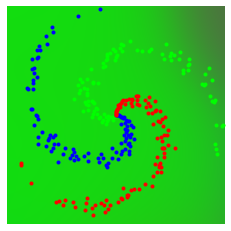

In [11]:
def plot_N(Net) :  # Net is a neural network
    plt.clf
    q=100  # grid resolution per axis
    t = np.linspace(-1,1,q)
    [Yg,Xg] = np.meshgrid(t,t)
    Z = np.vstack([Xg.flatten(), Yg.flatten()])
    V = Net.forward(Z)  # network output on the grid
    U = ilogit(V)  # apply ilogit
    U = np.reshape(U.transpose(), [q,q,3] )  # reshape for imshow
    plt.imshow(U.transpose((1, 0, 2)), origin="lower", extent=[-1,1,-1,1])  # RGB image of class probabilities
    for i in np.arange(n):
        plt.plot(x[0,i], x[1,i], '.', color=y[:,i])  # overlay training points
    plt.axis('off')
plot_N(N)

## Optimization

Run your optimization routine. For now use fixed-step gradient descent with step size $.01/15$. Recall: $x$ holds inputs and $y$ holds targets.
- Parameters are stored in a vector `C`; retrieve them with `C = get(N)` (or the equivalent in your code).
- Evaluate the network with `N.forward(x)`. If your implementation returns intermediate activations as a list `X_list`, the network output is the last tensor, `Z = X_list[-1]`.
- Apply `ilogit` to `Z`; call the result `tildeY`. The loss is `loss(y, tildeY)`. Each iteration, append this value to an array `cost` and plot it at the end.
- Compute the gradient of the last layer with `grad_loss`, then backpropagate with `N.backward`. Pack gradients into one vector with `recup_grad` (or your helper), take a gradient step on `C`, and write parameters back with `set(N, C)` (or `set_params`).
- Every $400$ iterations, print the cost and call `plot_N` on the grid (already provided).

Over to you...


Iteration 400, cost = 556.0294242254711


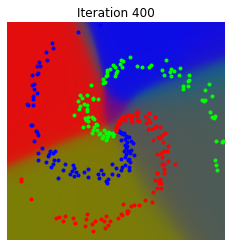

Iteration 800, cost = 611.3627907568576


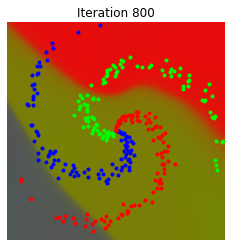

Iteration 1200, cost = 456.87705799764643


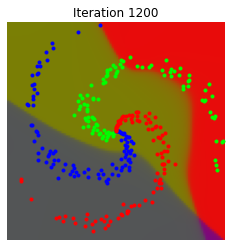

Iteration 1600, cost = 416.3917021566443


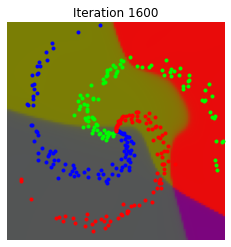

Iteration 2000, cost = 418.155973382791


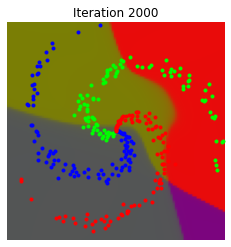

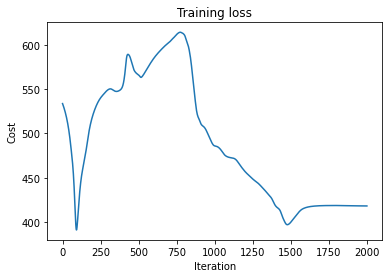

In [12]:
np.random.seed(42)
import Neural as Neur

N = Neur.Network([Neur.Dense(2,15), Neur.Arctan(), Neur.Dense(15,3), Neur.Arctan()])
N_a = Neur.Network([N, Neur.Ilogit_and_KL(y)])
step = 0.01 / 15
n_iter = 2000
cost = []
C = N_a.get_params()

for k in range(n_iter):
    N_a.set_params(C)
    loss = N_a.forward(x)
    cost.append(loss)
    grad_param, _ = N_a.backward(None)
    C = C - step * grad_param

    if (k+1) % 400 == 0:
        print(f"Iteration {k+1}, cost = {loss}")
        plt.figure()
        plot_N(N)
        plt.title(f"Iteration {k+1}")
        plt.show()

plt.figure()
plt.plot(cost)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Training loss")
plt.show()

# Background for the mathematically inclined
Later you will see classification models, in particular generalized linear models. One introduces a probabilistic model where for each input $x_{\bullet,p} \in \mathbb{R}^2$, the label $y_{\bullet,p}\in \mathbb{R}^3$ is random, equal to $[1,0,0]$ with probability $\pi_{1,p}$, $[0,1,0]$ with probability $\pi_{2,p}$, and $[0,0,1]$ with probability $\pi_{3,p}$.

Then $\tilde y$ is a $(3,p)$ matrix viewed as an estimator of the probability matrix $\pi$.
Typically one does not estimate $\pi$ directly but rather the "log-odds relative to class 1"—for all $p$ and $i\ne 1$,
$$ \ln\left(\frac {\pi_{i,p} }{\pi_{1,p}}\right)$$
Note that if $\pi =$ `ilogit`($\zeta$), then
$$ \ln\left(\frac {\pi_{i,p} }{\pi_{1,p}}\right)= \zeta_{i,p} -\zeta_{1,p}.$$
and the goal is to estimate $\zeta$.

In simple GLMs, writing $z$ for an estimator of $\zeta$, one often assumes $\zeta$ is linear in the inputs: a matrix $\hat \theta$ of shape $(3,2)$ with
$$ z_{\bullet,p}=\hat \theta x_{\bullet,p}$$
Here $z_{\bullet,p}$ is instead a nonlinear function of $x_{\bullet,p}$ given by a neural network.
